In [1640]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [1641]:
class Product:
    """Represents a product in the shop"""
    def __init__(self, r, s, S, c, h, order_price):
        self.r = r #cost of the product per unit for clients
        self.s = s #minimum amount of product before making a delivery to restock
        self.S = S #total amount of capacity
        self.x = S #actual capacity 
        self.h = h #aditional cost per unit

        self.c = c #total cost of the product to restock
        self.order_price = order_price ##cost per unit of the product to restock

        self.t1 = float("inf") #arriving time of an order
        self.y = 0 #amount of product to order

        self.capacity_trace = [self.S] #following the different available capacities during the simulation
        self.capacity_trace_time = [0]

        self.order_demand = [] #time when the shop demands for an order
        self.order_arrivals = [] #time of the arrival of the orders

    def check_stock(self, t, arriving_time):
        if self.x < self.s and self.y == 0: #the shop needs to make an order to restock
            self.order_demand.append(t) 
            self.y = self.S - self.x #amount to order
            self.t1 = t + arriving_time #time for the order to arrive

    def order_arrives(self):
        self.order_arrivals.append(self.t1) #an order arrives

    def reset_order(self):
        self.y = 0
        self.t1 = float("inf")

In [1642]:
class TheShopSimulation2:
    """Simulates the inventory model of a shop"""
    def __init__(self, lam, L, T, client_function, amount_function, initial_money, kinds_of_product: list[Product]):
        self.lam = lam #lambda for Poisson
        self.T = T #time limit for the simulation
        self.kinds_of_product = kinds_of_product 

        self.L = L #units of time until the order is delivered
        self.client_function = client_function #time distribution for clients
        self.amount_function = amount_function #distribution for amount of product to sell to client

        self.t = 0 #actual time
        self.t0 = self.client_function(self.lam) #arriving time of a client

        self.C = 0 # the total amount of ordering costs by t
        self.H = 0 #the total amount of inventory holding costs by t
        self.R = 0 #the total amount of revenue earned by time t

        self.revenue_trace = [initial_money] #following the amounts of revenue earned
        self.revenue_trace_time = [0]

        self.client_arrivals = [] #time of the arrival of the clients

    def new_customer(self):
        """New customer arrives, buys some product and the shop makes an order depending of the capacity"""
        
        self.client_arrivals.append(self.t0) #a client arrives
        
        xs = [product.x for product in self.kinds_of_product]
        hs = [product.h for product in self.kinds_of_product]
        inventory_holding = (self.t0 - self.t) * np.array(xs) * np.array(hs)
        self.revenue_trace.append(self.revenue_trace[len(self.revenue_trace)-1] - np.array(inventory_holding).sum())
        self.revenue_trace_time.append(self.t)

        self.H += np.array(inventory_holding).sum() #the cost of inventory holding acumulates
        self.t = self.t0 #update current time

        D = self.amount_function(len(self.kinds_of_product))
        actual_capacity = [product.x for product in self.kinds_of_product]
        w = np.minimum(D, actual_capacity)

        rs = [product.r for product in self.kinds_of_product]
        revenues = np.array(rs) * np.array(w)

        self.R += np.array(revenues).sum()
        self.revenue_trace.append(self.revenue_trace[len(self.revenue_trace)-1] + np.array(revenues).sum())
        self.revenue_trace_time.append(self.t)

        for i in range(0, len(self.kinds_of_product)): self.kinds_of_product[i].x -= w[i] #losing product
        for i in range(0, len(self.kinds_of_product)): 
            self.kinds_of_product[i].capacity_trace.append(self.kinds_of_product[i].x)
            self.kinds_of_product[i].capacity_trace_time.append(self.t)

        for i in range(0, len(self.kinds_of_product)): self.kinds_of_product[i].check_stock(self.t, abs(self.L())) #the shop needs to make an order to restock

        self.t0 += self.client_function(self.lam) #time for a new customer to come

    def new_order(self, i):
        """The order arrives"""
        self.kinds_of_product[i].order_arrives() #an order arrives

        xs = [product.x for product in self.kinds_of_product]
        hs = [product.h for product in self.kinds_of_product]
        inventory_holding = (self.kinds_of_product[i].t1 - self.t) * np.array(xs) * np.array(hs)
        self.revenue_trace.append(self.revenue_trace[len(self.revenue_trace)-1] - np.array(inventory_holding).sum())
        self.revenue_trace_time.append(self.t)

        self.H += np.array(inventory_holding).sum() #the cost of inventory holding acumulates
        self.t = self.kinds_of_product[i].t1 #update current time

        cost = self.kinds_of_product[i].c(self.kinds_of_product[i].y, self.kinds_of_product[i].order_price)
        self.revenue_trace.append(self.revenue_trace[len(self.revenue_trace)-1] - cost)
        self.revenue_trace_time.append(self.t)
        
        self.C += cost #update costs

        self.kinds_of_product[i].x += self.kinds_of_product[i].y
        self.kinds_of_product[i].capacity_trace.append(self.kinds_of_product[i].x)
        self.kinds_of_product[i].capacity_trace_time.append(self.t)

        #no new order needed
        self.kinds_of_product[i].reset_order()

    def run(self):
        """Runs the simulation until time T and returns an estimate of the total earnings"""
        while self.t < self.T:
            minimum = float("inf")
            i = 0
            j = i
            for product in self.kinds_of_product:
                if product.t1 < minimum:
                    minimum = product.t1
                    j = i
                i += 1
            if self.t0 < minimum: self.new_customer()
            else: self.new_order(j)
        return (self.R - self.C - self.H)/self.T

In [1643]:
def client_function(lam):
    """Time for the client to come"""
    u = np.random.uniform()
    return -(1/lam)*np.log(u)
    
def amount_function(amount_products):
    """Amount of each product that the client is buying"""
    # lambdas = np.random.uniform(0, 5, size=amount_products) #mean demand between 0 and 5 each client
    lambdas = np.random.exponential(scale=1.5, size=amount_products) #low amount of high requested products and high amount of low requested products
    demand = np.random.poisson(lambdas) #generating an array of each kind of product wich the client is buying
    return demand

def L():
    """Time for the order to come"""
    time = np.random.normal(2, 1.5)
    #print(f"Order arrives in: {time}")
    return max(1, time)

def c(y, cost):
    """Total cost per unit of product of the order"""
    total_cost = 0
    for i in range(y):
        total_cost += cost
    return total_cost

In [1644]:
#generating new products
products = [
    Product(35, 25, 50, c, 2, 8), #vainilla
    Product(40, 25, 50, c, 2, 18), #fresa
    Product(45, 25, 50, c, 2, 28), #mantecado
    Product(50, 25, 50, c, 2, 38), #almendra
    Product(55, 25, 50, c, 2, 48) #chocolate
]

In [1645]:
sim = TheShopSimulation2(
        lam = 1.5,
        L = L,
        T = 100,
        client_function=client_function,
        amount_function=amount_function,
        initial_money=100,
        kinds_of_product=products
        )
estimate = sim.run()
print(estimate)

-86.56995987124661


## Es suficiente el inventario actual con respecto a la demanda?

In [1646]:
# for i in range(0, len(products)):
#     plt.figure(figsize=(40, 20))
#     plt.vlines(sim.client_arrivals, ymin=0, ymax=sim.kinds_of_product[i].S, color='orange', linestyles='dashed', label='Llega un cliente')
#     plt.vlines(sim.kinds_of_product[i].order_demand, ymin=0, ymax=sim.kinds_of_product[i].S, color='red', linestyles='dashed', label='Se hace un pedido')
#     plt.vlines(sim.kinds_of_product[i].order_arrivals, ymin=0, ymax=sim.kinds_of_product[i].S, color='green', linestyles='dashed', label='LLegó un pedido')
#     plt.step(sim.kinds_of_product[i].capacity_trace_time, sim.kinds_of_product[i].capacity_trace, where='post', label='Inventario')
#     plt.xlabel('Tiempo')
#     plt.ylabel('Unidades en inventario')
#     plt.title(f'Momentos de pedido y evolución del inventario del producto: {i+1}')
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

## Veamos como se comportan las ganancias con el pasar del tiempo

In [1647]:
# plt.figure(figsize=(20, 20))
# plt.plot(sim.revenue_trace_time, sim.revenue_trace, marker='o')
# plt.xlabel("Tiempo transcurrido")
# plt.ylabel("Rastro de ganancias")
# plt.title("Ganancia-perdida en la tienda con respecto al tiempo")
# plt.grid(True)
# plt.show()

### Bootstrap

In [1648]:
def bootstrap(initial_sample, estimator=np.mean, number_bootstraps=1000):
    bootstrap_samples = []
    sample_size = len(initial_sample)
    for _ in range(number_bootstraps):
        sample = np.random.choice(initial_sample, size=sample_size, replace=True)
        bootstrap_samples.append(estimator(sample))
    return bootstrap_samples

## Prueba de hipótesis 1: Disminuir s y S mejora las ganancias?

In [1649]:
#generating new products
products2 = [
    Product(35, 5, 20, c, 2, 8), #vainilla
    Product(40, 5, 20, c, 2, 18), #fresa
    Product(45, 5, 20, c, 2, 28), #mantecado
    Product(50, 5, 20, c, 2, 38), #almendra
    Product(55, 5, 20, c, 2, 48) #chocolate
]

In [1650]:
#do 100 simulations with low s and S
estimates1 = []
for i in range (0,100):
    sim = TheShopSimulation2(
        lam = 1.5,
        L = L,
        T = 100,
        client_function=client_function,
        amount_function=amount_function,
        initial_money=100,
        kinds_of_product=products2
    )
    estimate = sim.run()
    estimates1.append(estimate)

print(estimates1)

bootstrap_samples1 = bootstrap(initial_sample=estimates1, estimator=np.mean, number_bootstraps=1000)
mean_earnings1 = np.mean(bootstrap_samples1)
print(mean_earnings1)

[67.89900456324489, 34.11385355153739, 50.20392093954421, 7.388916610141551, 1.0506984016107253, 13.368023597157967, 4.260899396165869, 1.162867989409783, 2.459054198455622, 2.039054520060599, 4.926661955953814, 1.1688612217885292, 8.740918556394286, 8.776375972592321, -3.6206449016460374, 12.374613417371204, 0.0, -6.08, 7.037852013066374, 17.044700085591767, 4.792862350340738, 24.064132180850997, 23.97776898041107, 14.466402997244808, 11.98586317631134, 12.525582148184762, -6.08, 2.9308630127535706, 5.904792395040793, 3.920305084869592, 17.095836706460776, 11.878462184385285, 8.268381398575302, 44.0402897192797, 1.4603278868842053, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -4.76, 19.46116985237986, 1.342349247181223, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
4.32

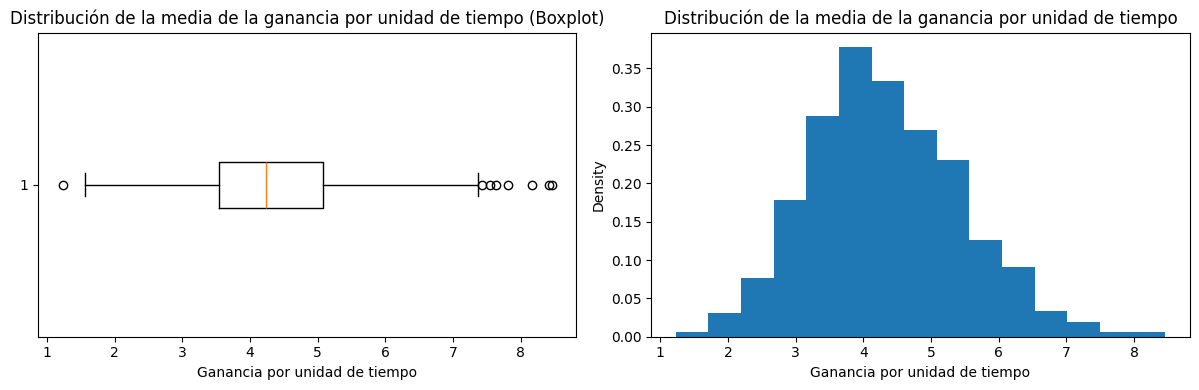

In [1651]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.boxplot(bootstrap_samples1, vert=False)
plt.title('Distribución de la media de la ganancia por unidad de tiempo (Boxplot)')
plt.xlabel('Ganancia por unidad de tiempo')
plt.subplot(1, 2, 2)
plt.hist(bootstrap_samples1, bins=15, density=True)
plt.title('Distribución de la media de la ganancia por unidad de tiempo')
plt.xlabel('Ganancia por unidad de tiempo')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [1652]:
#trust interval
ic_inf, ic_sup = np.percentile(bootstrap_samples1, [2.5, 97.5])

print(f"Intervalo de confianza 95%: [{ic_inf:.2f}, {ic_sup:.2f}]")
if ic_inf > 0:
    print("Rechazamos H0: la media es significativamente mayor que 0.")
else:
    print("No hay evidencia suficiente para rechazar H0.")

Intervalo de confianza 95%: [2.33, 6.68]
Rechazamos H0: la media es significativamente mayor que 0.


## Prueba de hipótesis 2: Aumentar más los precios mejora las ganancias?

In [1653]:
#generating new products
products3 = [
    Product(80, 25, 50, c, 2, 8), #vainilla
    Product(85, 25, 50, c, 2, 18), #fresa
    Product(90, 25, 50, c, 2, 28), #mantecado
    Product(95, 25, 50, c, 2, 38), #almendra
    Product(100, 25, 50, c, 2, 48) #chocolate
]

In [1654]:
#do 100 simulations with low s and S
estimates2 = []
for i in range (0,100):
    sim = TheShopSimulation2(
        lam = 1.5,
        L = L,
        T = 100,
        client_function=client_function,
        amount_function=amount_function,
        initial_money=100,
        kinds_of_product=products2
    )
    estimate = sim.run()
    estimates2.append(estimate)

print(estimates2)

bootstrap_samples2 = bootstrap(initial_sample=estimates2, estimator=np.mean, number_bootstraps=1000)
mean_earnings2 = np.mean(bootstrap_samples2)
print(mean_earnings2)

[0.0, 0.0, 0.0, -4.76, 16.477419674325073, 15.211580185270696, 9.472019521737048, 11.445523673891401, 17.9394351535293, -5.32, 16.629052731816042, 12.853926812722397, 19.930160646807874, -5.32, 24.04629229772079, 11.44504274092899, 13.399895956463405, 23.71345567685656, 15.751503186895839, 17.227305010102526, 18.34475655867674, 24.953249874268703, 26.000225234808855, 20.016742121692417, 22.42086028522868, 23.299282818279984, 11.48345451556368, 14.413417040728053, 23.348554691641443, 27.427857593508826, 32.16671972844154, 22.555946265302897, 23.957056044760133, 22.162062621112373, 22.793760007552734, 20.701940178061466, 20.638462376713964, 21.883287944753402, 0.0, 0.0, -3.06, 29.12018685316605, 23.006343046253207, 26.92306182459733, 20.950404797999184, 28.52050197872335, 23.61382777024676, 1.1750956792101726, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

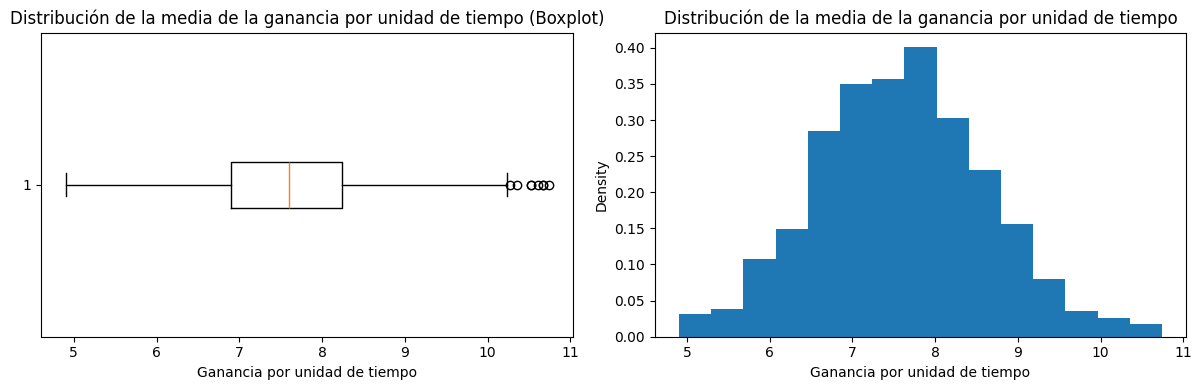

In [1655]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.boxplot(bootstrap_samples2, vert=False)
plt.title('Distribución de la media de la ganancia por unidad de tiempo (Boxplot)')
plt.xlabel('Ganancia por unidad de tiempo')
plt.subplot(1, 2, 2)
plt.hist(bootstrap_samples2, bins=15, density=True)
plt.title('Distribución de la media de la ganancia por unidad de tiempo')
plt.xlabel('Ganancia por unidad de tiempo')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [1656]:
#trust interval
ic_inf2, ic_sup2 = np.percentile(bootstrap_samples2, [2.5, 97.5])

print(f"Intervalo de confianza 95%: [{ic_inf2:.2f}, {ic_sup2:.2f}]")
if ic_inf2 > 0:
    print("Rechazamos H0: la media es significativamente mayor que 0.")
else:
    print("No hay evidencia suficiente para rechazar H0.")

Intervalo de confianza 95%: [5.65, 9.73]
Rechazamos H0: la media es significativamente mayor que 0.


Version no generalizada para varios productos

In [1657]:
# class TheShopSimulation:
#     """Simulates the inventory model of a shop"""
    
#     def __init__(self, lam, r, s, S, L, c, h, T, client_function, amount_function, initial_money):
#         self.r = r #cost of a product per unit for clients
#         self.s = s #minimum amount of product before making a delivery to restock
#         self.S = S #total amount of capacity
#         self.x = S #actual capacity 
#         self.h = h #aditional cost per unit
#         self.lam = lam #lambda for Poisson
#         self.T = T #time limit for the simulation
        
#         self.L = L #units of time until the order is delivered
#         self.client_function = client_function #time distribution for clients
#         self.amount_function = amount_function #distribution for amount of product to sell to client
#         self.c = c #cost per unit of the product to restock

#         self.events = {'customer_arriving': self.new_customer,
#                        'order_arriving': self.new_order
#                        }
#         self.t = 0 #actual time
#         self.y = 0 #amount of product to order
#         self.t0 = self.client_function(self.lam) #arriving time of a client
#         self.t1 = float("inf") #arriving time of an order
#         self.C = 0 # the total amount of ordering costs by t
#         self.H = 0 #the total amount of inventory holding costs by t
#         self.R = 0 #the total amount of revenue earned by time t

#         self.revenue_trace = [initial_money] #following the amounts of revenue earned
#         self.cost_trace = [0] #following the costs
#         self.hold_trace = [0] #following the inventory holding
#         self.capacity_trace = [self.S] #following the different available capacities during the simulation

#         self.revenue_trace_time = [0]

#         self.time_trace = [0] #time lapses
#         self.client_arrivals = [] #time of the arrival of the clients
#         self.order_arrivals = [] #time of the arrival of the orders
#         self.order_demand = [] #time when the shop demands for an order
        
#     def new_customer(self):
#         """New customer arrives, buys some product and the shop makes an order depending of the capacity"""
#         self.client_arrivals.append(self.t0) #a client arrives

#         inventory_holding = (self.t0 - self.t) * self.x * self.h
#         self.revenue_trace.append(self.revenue_trace[len(self.revenue_trace)-1] - inventory_holding)
#         self.revenue_trace_time.append(self.t)

#         self.H += inventory_holding #the cost of inventory holding acumulates
#         self.hold_trace.append(self.H)

#         self.t = self.t0 #update current time
#         self.time_trace.append(self.t)

#         D = self.amount_function() #amount of product demanded by the client
#         w = min(D, self.x) #selling the available amount of product

#         revenue = w * self.r
#         self.R += revenue #revenue acumulates
#         self.revenue_trace.append(self.revenue_trace[len(self.revenue_trace)-1] + revenue)
#         self.revenue_trace_time.append(self.t)

#         self.x -= w #losing product
#         #print(f"Actual capacity: {self.x}")
#         self.capacity_trace.append(self.x)

#         if self.x < self.s and self.y == 0: #the shop needs to make an order to restock
#             self.order_demand.append(self.t) 
#             self.y = self.S - self.x #amount to order
#             self.t1 = self.t + abs(self.L(self.lam)) #time for the order to arrive
#         self.t0 += self.client_function(self.lam) #time for a new customer to come

#     def new_order(self):
#         """The order arrives"""
#         self.order_arrivals.append(self.t1) #an order arrives

#         inventory_holding = (self.t1 - self.t) * self.x * self.h
#         self.revenue_trace.append(self.revenue_trace[len(self.revenue_trace)-1] - inventory_holding)
#         self.revenue_trace_time.append(self.t)

#         self.H += inventory_holding #the cost of inventory holding acumulates
#         self.hold_trace.append(self.H)

#         self.t = self.t1 #update current time
#         self.time_trace.append(self.t)

#         cost = self.c(self.y)
#         self.revenue_trace.append(self.revenue_trace[len(self.revenue_trace)-1] - cost)
#         self.revenue_trace_time.append(self.t)
        
#         self.C += cost #update costs
#         self.cost_trace.append(self.C)

#         self.x += self.y #update new product to restock
#         #print(f"Actual capacity: {self.x}")
#         self.capacity_trace.append(self.x)
        
#         #no new order needed
#         self.y = 0 
#         self.t1 = float("inf")

#     def run(self):
#         """Runs the simulation until time T and returns an estimate of the total earnings"""
#         while self.t < self.T:
#             if self.t0 < self.t1: self.new_customer()
#             else: self.new_order()
#         return (self.R - self.C - self.H) / self.T #estimate the total earnings per unit time


In [1658]:
# def client_function(lam):
#     """Time for the client to come"""
#     u = np.random.uniform()
#     return -(1/lam)*np.log(u)
#     #time = np.random.exponential(1/lam)
#     #print(f"Client arrives: {time}")
#     return time
    
# def amount_function():
#     """Amount of product that the client is buying"""
#     prob = np.random.uniform()
#     amount = np.random.binomial(100, prob)
#     #print(f"Client buys: {amount}")
#     return amount

# def L(lam):
#     """Time for the order to come"""
#     time = np.random.normal(2, 1.5)
#     #print(f"Order arrives in: {time}")
#     return time

# def c(y):
    """Total cost per unit of product of the order"""
    cost = 0
    for i in range(y):
        cost += 5
    return cost

IndentationError: unexpected indent (1910310738.py, line 23)

In [ ]:
# sim = TheShopSimulation(
#         lam = 1.5,
#         r = 8.99,
#         s = 50,
#         S = 100,
#         L = L,
#         c = c,
#         h = 3,
#         T = 100,
#         client_function=client_function,
#         amount_function=amount_function,
#         initial_money=100
#         )
# estimate = sim.run()
# print(estimate)

21.235210438626655


## Es suficiente la capacidad actual con respecto a la demanda?
Veamos como se comporta la capacidad con el pasar del tiempo

ValueError: x and y must have same first dimension, but have shapes (193,) and (194,)

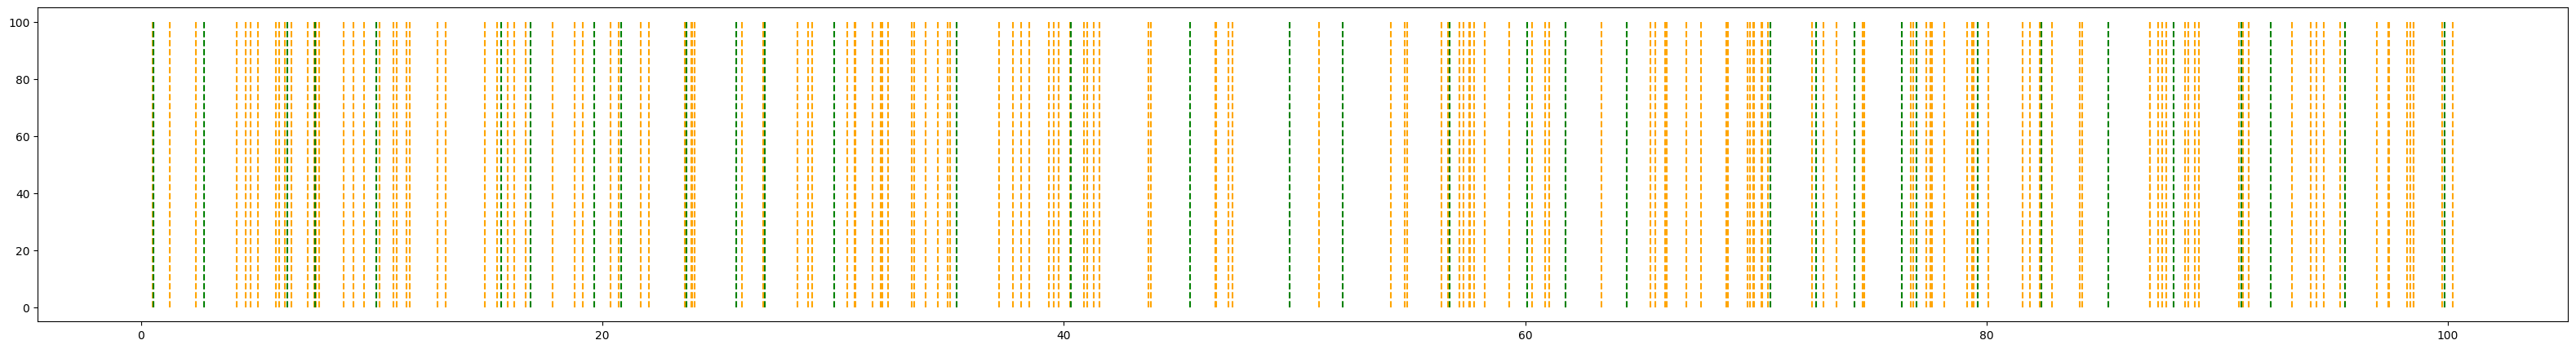

In [ ]:
# plt.figure(figsize=(40, 5))
# plt.vlines(sim.client_arrivals, ymin=0, ymax=sim.S, color='orange', linestyles='dashed', label='Pedidos realizados')
# plt.vlines(sim.order_arrivals, ymin=0, ymax=sim.S, color='green', linestyles='dashed', label='LLegó un pedido')
# plt.step(sim.time_trace[1:], sim.capacity_trace, where='post', label='Inventario')
# plt.xlabel('Tiempo')
# plt.ylabel('Unidades en inventario')
# plt.title('Momentos de pedido y evolución del inventario')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Cómo se comporta la ganancia-perdida en la tienda con respecto al tiempo?

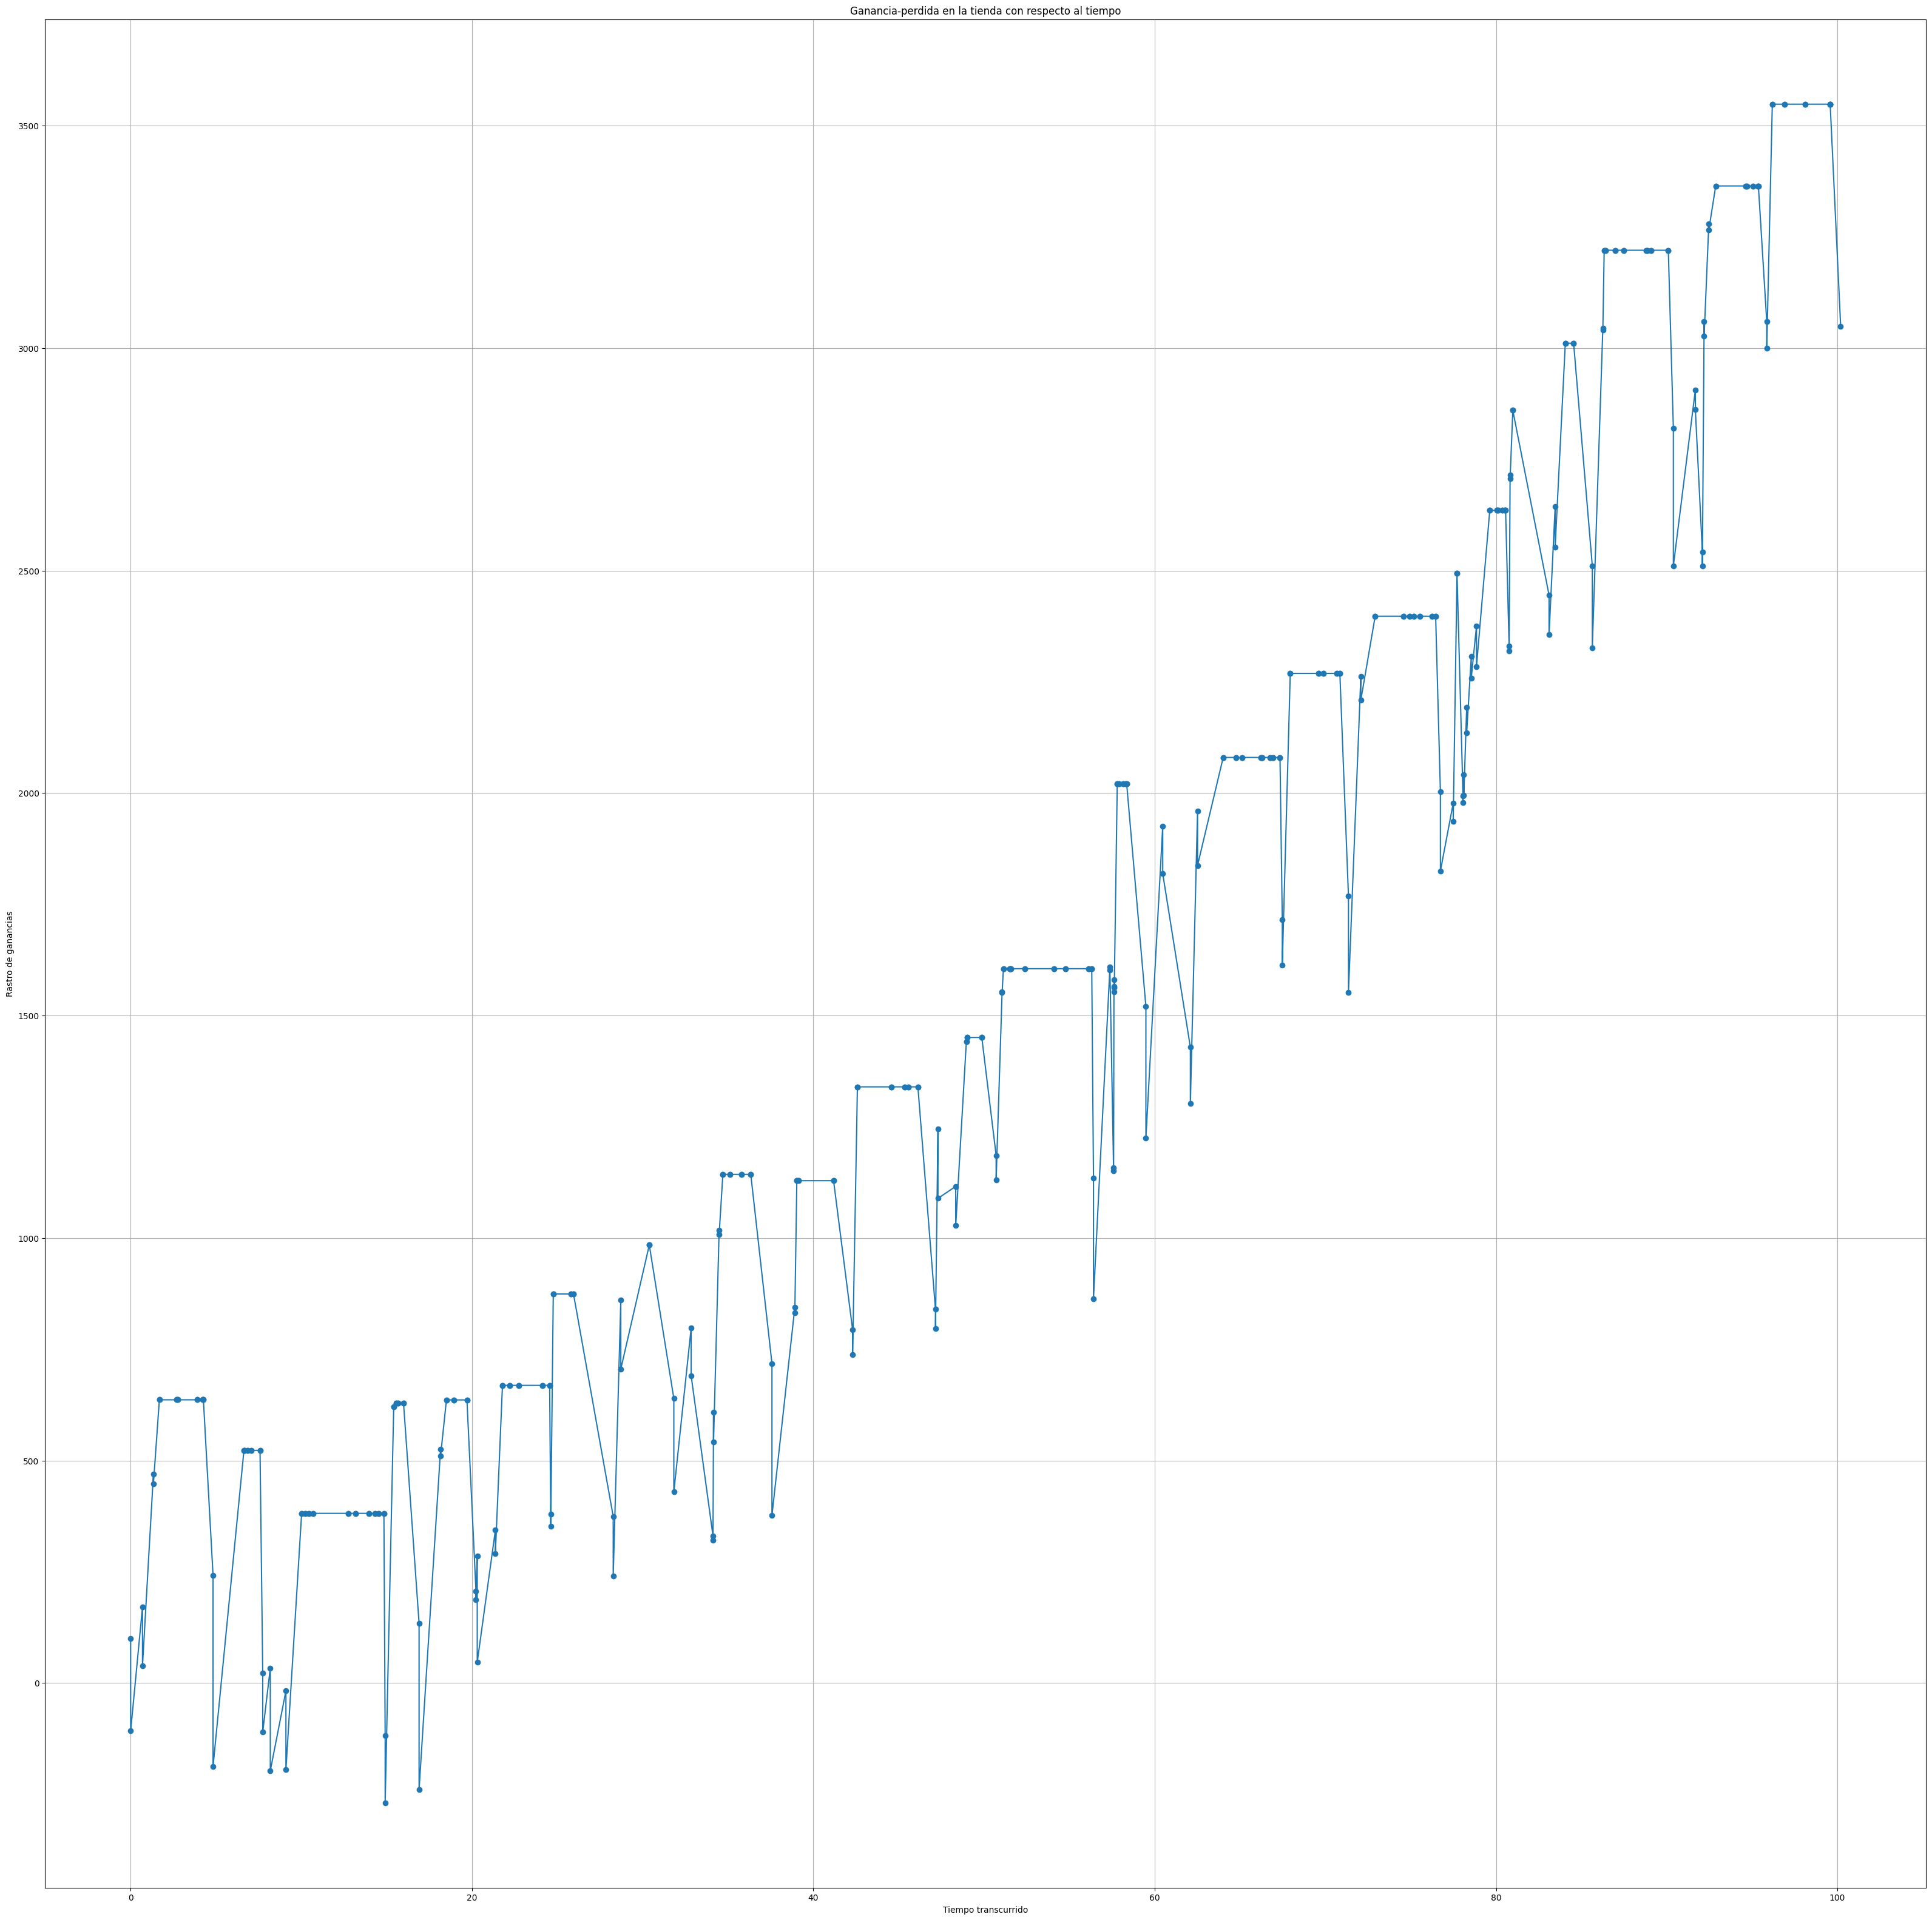

In [ ]:
# plt.figure(figsize=(40, 40))
# plt.plot(sim.revenue_trace_time, sim.revenue_trace, marker='o')
# plt.xlabel("Tiempo transcurrido")
# plt.ylabel("Rastro de ganancias")
# plt.title("Ganancia-perdida en la tienda con respecto al tiempo")
# plt.grid(True)
# plt.show()

 Existe relacion entre la ganancia por unidad de tiempo estimada y el limite minimo de inventario que se debe tener antes de hacer un pedido?

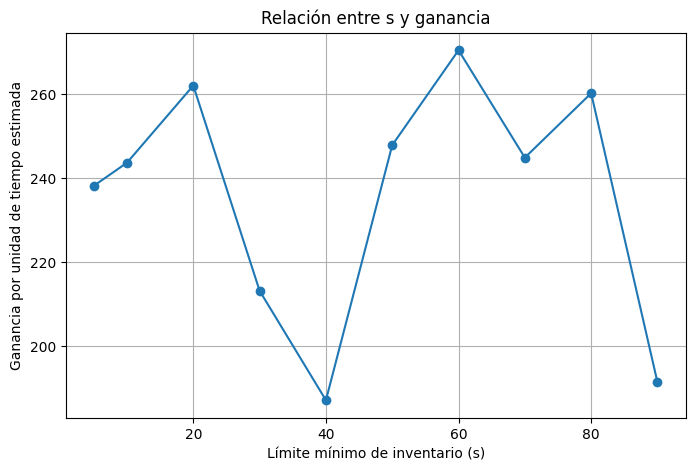

Coeficiente de correlación de Pearson: -0.101 (p-value=0.7811)


In [ ]:
# minimum = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# estimates = []

# for i in range(0, len(minimum)):
#     sim = TheShopSimulation(
#         lam = 1.5,
#         r = 16.99,
#         s = minimum[i],
#         S = 100,
#         L = L,
#         c = c,
#         h = 3,
#         T = 100,
#         client_function=client_function,
#         amount_function=amount_function,
#         initial_money=100
#         )
#     estimate = sim.run()
#     estimates.append(estimate)

# plt.figure(figsize=(8,5))
# plt.plot(minimum, estimates, marker='o')
# plt.xlabel("Límite mínimo de inventario (s)")
# plt.ylabel("Ganancia por unidad de tiempo estimada")
# plt.title("Relación entre s y ganancia")
# plt.grid(True)
# plt.show()

# correlacion, p_value = stats.pearsonr(minimum, estimates)
# print(f"Coeficiente de correlación de Pearson: {correlacion:.3f} (p-value={p_value:.4f})")

## Bootstrap

In [ ]:
def bootstrap(initial_sample, estimator=np.mean, number_bootstraps=1000):
    bootstrap_samples = []
    sample_size = len(initial_sample)
    for _ in range(number_bootstraps):
        sample = np.random.choice(initial_sample, size=sample_size, replace=True)
        bootstrap_samples.append(estimator(sample))
    return bootstrap_samples

## Prueba de hipotesis:
Si por cada producto su precio de venta es 17, es este rpecio factible para la tienda? En otras palabras, la media de ganancias por unidad de tiempo es mayor que cero?

292.6899245111636


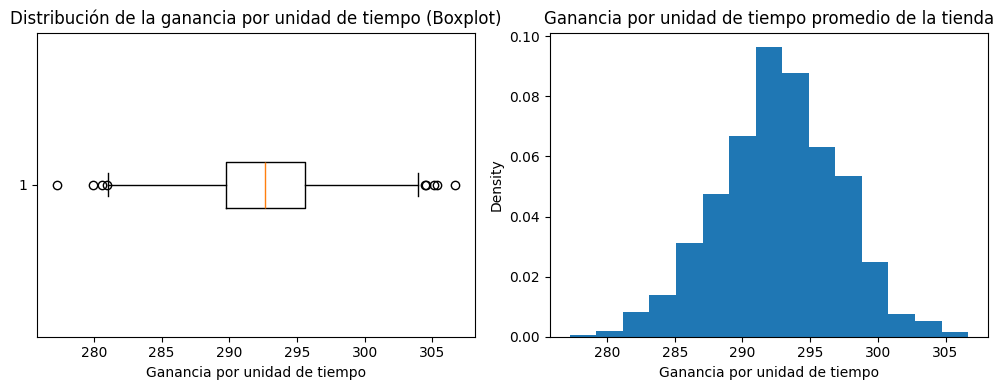

In [ ]:
# estimates = []
# for i in range(0, 100):
#     sim = TheShopSimulation(
#         lam = 1.5,
#         r = 16.99,
#         s = 50,
#         S = 200,
#         L = L,
#         c = c,
#         h = 3,
#         T = 100,
#         client_function=client_function,
#         amount_function=amount_function,
#         initial_money=100
#         )
#     estimate = sim.run()
#     estimates.append(estimate)

# bootstrap_samples = bootstrap(initial_sample=estimates, estimator=np.mean, number_bootstraps=1000)
# mean_earnings = np.mean(bootstrap_samples)
# print(mean_earnings)

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.boxplot(bootstrap_samples, vert=False)
# plt.title('Distribución de la ganancia por unidad de tiempo (Boxplot)')
# plt.xlabel('Ganancia por unidad de tiempo')
# plt.subplot(1, 2, 2)
# plt.hist(bootstrap_samples, bins=15, density=True)
# plt.title('Ganancia por unidad de tiempo promedio de la tienda')
# plt.xlabel('Ganancia por unidad de tiempo')
# plt.ylabel('Density')

# plt.tight_layout()
# plt.show()

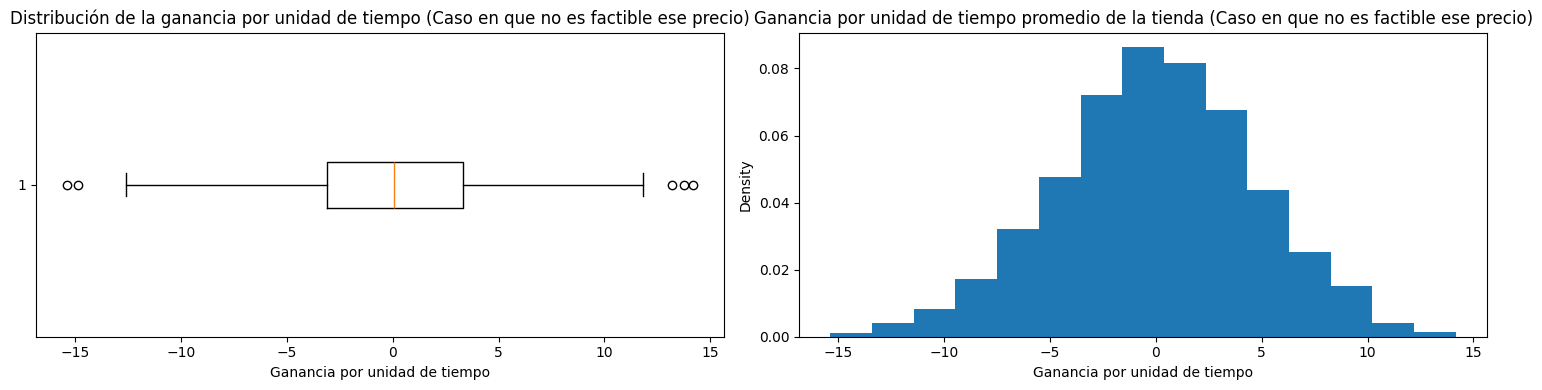

In [ ]:
# mean = np.mean(estimates)
# new_sample = estimates - mean

# bootstrap_samples2 = bootstrap(initial_sample=new_sample, estimator=np.mean, number_bootstraps=1000)
# mean_earnings2 = np.mean(bootstrap_samples2)

# plt.figure(figsize=(15, 4))
# plt.subplot(1, 2, 1)
# plt.boxplot(bootstrap_samples2, vert=False)
# plt.title('Distribución de la ganancia por unidad de tiempo (Caso en que no es factible ese precio)')
# plt.xlabel('Ganancia por unidad de tiempo')
# plt.subplot(1, 2, 2)
# plt.hist(bootstrap_samples2, bins=15, density=True)
# plt.title('Ganancia por unidad de tiempo promedio de la tienda (Caso en que no es factible ese precio)')
# plt.xlabel('Ganancia por unidad de tiempo')
# plt.ylabel('Density')

# plt.tight_layout()
# plt.show()

In [ ]:
# p_value = np.mean(bootstrap_samples2 >= mean_earnings)

# print(f"Valor-p (unilateral): {p_value:.4f}")
# if p_value <= 0.05:
#     print(f"Se rechaza la hipótesis nula de que la ganancia es factible con un precio de 17 por unidad")
# else:
#     print(f"Fallamos al rechazar la hipótesis nula de que la ganancia es factible con un precio de 17 por unidad")

Valor-p (unilateral): 0.0000
Se rechaza la hipótesis nula de que la ganancia es factible con un precio de 17 por unidad
